# GP-UCB Bayesian Optimization for TX-TL Productivity (Baseline)

This notebook defines a GP-UCB baseline to compare against LLM-based optimization.
The oracle (ridge-regression surrogate) is the same as in the LLM benchmark; budget is **30 queries per run**.

**Pipeline:**
1. **Random initialization:** one random starting point (no LLM); query oracle → initial dataset D
2. Fit GP on D: f(x)|D ~ N(μ(x), σ²(x))
3. Propose next x by maximising UCB: a(x) = μ(x) + κ·σ(x)
4. Query oracle at x, append to D, refit, repeat

Results are aggregated over many runs (e.g. 100) with **stepwise mean and 95% CI** reported.

In [6]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cross_check
importlib.reload(cross_check)
from cross_check import load_experiments

import gp_optimizer as gpo
importlib.reload(gpo)

df_experiments = load_experiments()
print(f'Loaded {len(df_experiments)} experiments')
print(f'Feature vector dimension: {gpo.N_FEATURES} ({gpo.N_NUMERIC} numeric + {gpo.N_ONEHOT} one-hot)')

Loaded 49 experiments
Feature vector dimension: 19 (7 numeric + 12 one-hot)


In [7]:
rng_test = np.random.default_rng(0)
h = gpo.random_hypothesis(rng_test)
print(f'Sample hypothesis: {h}')
print(f'Encoded length:    {len(gpo.encode_hypothesis(h))}')
print(f'Oracle score:      {gpo.oracle_score(h):.4f} mg/mL/hr')
print(f'Round-trip:        {gpo.decode_feature_vector(gpo.encode_hypothesis(h))}')

Sample hypothesis: {'Mg_glutamate_mM': 5.27, 'K_glutamate_mM': 65.4, 'DTT_mM': 0.12, 'NTP_multiplier': 1.03, 'PEG_8000_percent': 4.07, 'temperature_C': 30.0, 'plasmid_concentration_nM': 8.03, 'energy_source': '3-PGA + maltodextrin', 'extract_type': 'KC6', 'chaperones': 'DnaK/DnaJ/GrpE', 'reaction_mode': 'semi-continuous'}
Encoded length:    19
Oracle score:      0.3559 mg/mL/hr
Round-trip:        {'Mg_glutamate_mM': np.float64(5.27), 'K_glutamate_mM': np.float64(65.4), 'DTT_mM': np.float64(0.12), 'NTP_multiplier': np.float64(1.03), 'PEG_8000_percent': np.float64(4.07), 'temperature_C': np.float64(30.0), 'plasmid_concentration_nM': np.float64(8.03), 'energy_source': '3-PGA + maltodextrin', 'extract_type': 'KC6', 'chaperones': 'DnaK/DnaJ/GrpE', 'reaction_mode': 'semi-continuous'}


## Run GP-UCB optimisation

100 independent runs, 30 oracle queries each (matching LLM benchmark budget).

In [ ]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

N_TOTAL = 30
N_SEED  = 1
KAPPA   = 2.0
N_RUNS  = 100   # increase as needed

gp_results = gpo.run_multiple(
    n_runs=N_RUNS, n_total=N_TOTAL, n_seed=N_SEED,
    kappa=KAPPA, n_candidates=100, base_seed=42,
)

gp_bests = [r['best_y'] for r in gp_results]

# Cumulative-max stats (best-so-far at each step, for convergence plots)
cum_mean, cum_se, cum_ci95_lo, cum_ci95_hi = gpo.stepwise_stats(gp_results, cumulative=True)

# Raw per-step stats (mean oracle score at each step, no accumulation)
step_mean, step_se, step_ci95_lo, step_ci95_hi = gpo.stepwise_stats(gp_results, cumulative=False)

print(f'\nGP (n={N_RUNS}): final best mean = {np.mean(gp_bests):.4f} +/- {np.std(gp_bests):.4f} mg/mL/hr')
print(f'GP (n={N_RUNS}): final best 95% CI = '
      f'[{np.mean(gp_bests) - 1.96*np.std(gp_bests)/np.sqrt(N_RUNS):.4f}, '
      f'{np.mean(gp_bests) + 1.96*np.std(gp_bests)/np.sqrt(N_RUNS):.4f}]')

step_df = pd.DataFrame({
    'query': np.arange(1, N_TOTAL + 1),
    'mean': step_mean, 'ci95_lo': step_ci95_lo, 'ci95_hi': step_ci95_hi,
})
display(step_df)

import json
gp_stats = {
    'n_runs': N_RUNS,
    'n_total': N_TOTAL,
    'n_seed': N_SEED,
    'kappa': KAPPA,
    'cum_mean': cum_mean.tolist(),
    'cum_ci95_lo': cum_ci95_lo.tolist(),
    'cum_ci95_hi': cum_ci95_hi.tolist(),
    'step_mean': step_mean.tolist(),
    'step_ci95_lo': step_ci95_lo.tolist(),
    'step_ci95_hi': step_ci95_hi.tolist(),
}
with open('gp_stepwise_stats.json', 'w') as f:
    json.dump(gp_stats, f, indent=2)
print(f'Saved GP stepwise stats to gp_stepwise_stats.json')

  Completed 1/100 runs...
  Completed 50/100 runs...
  Completed 100/100 runs...

GP (n=100): final best mean = 0.4240 +/- 0.0068 mg/mL/hr
GP (n=100): final best 95% CI = [0.4227, 0.4253]


,query,mean,ci95_lo,ci95_hi
0,1,0.203767,0.187376,0.220157
1,2,0.219696,0.202585,0.236808
2,3,0.243635,0.225945,0.261326
3,4,0.248851,0.231345,0.266357
4,5,0.275353,0.258929,0.291778
5,6,0.287394,0.272656,0.302132
6,7,0.316084,0.302705,0.329463
7,8,0.311837,0.298346,0.325327
8,9,0.328703,0.315961,0.341445
9,10,0.340953,0.330488,0.351418


Saved GP stepwise stats to gp_stepwise_stats.json


## GP results plots

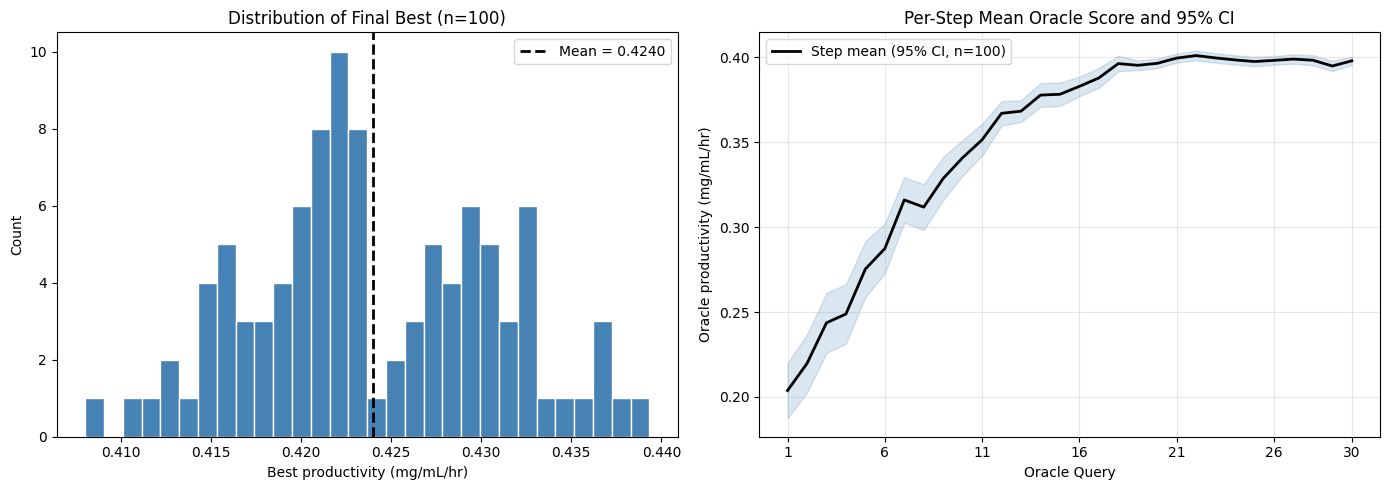

Oracle optimal: 0.5184 mg/mL/hr
95% CI: [0.3668, 0.6700]
Experimental optimal so far: 0.42 mg/mL/hr

Best GP hypothesis (run 61, oracle=0.4393):
  Mg_glutamate_mM                = 5.98
  K_glutamate_mM                 = 65.98
  DTT_mM                         = 2.77
  NTP_multiplier                 = 1.45
  PEG_8000_percent               = 0.08
  temperature_C                  = 25.0
  plasmid_concentration_nM       = 5.48
  energy_source                  = 3-PGA + maltose
  extract_type                   = KC6
  chaperones                     = combined
  reaction_mode                  = semi-continuous


In [9]:
oracle_meta = gpo.load_oracle_model()
loo_rmse = oracle_meta["model"]["metrics_loo"]["rmse"]
oracle_optimal = 0.5184
experimental_optimal = 0.42
t_crit = 2.011  # t(48, 0.975)
ci_margin = t_crit * loo_rmse
ci_lower = oracle_optimal - ci_margin
ci_upper = oracle_optimal + ci_margin

run_bests = [r['best_y'] for r in gp_results]
iters = np.arange(1, N_TOTAL + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if N_RUNS <= 20:
    run_labels = [f'GP run {i+1} (seed={r["random_state"]})' for i, r in enumerate(gp_results)]
    sorted_idx = np.argsort(run_bests)
    axes[0].barh(
        [run_labels[i] for i in sorted_idx],
        [run_bests[i] for i in sorted_idx],
        color='steelblue')
    for i, res in enumerate(gp_results):
        y_hist = np.array(res['y_history'])
        axes[1].plot(iters, y_hist, marker='o', markersize=3,
                     label=f'Run {i+1} (seed={res["random_state"]})')
else:
    axes[0].hist(run_bests, bins=min(30, N_RUNS // 3), color='steelblue', edgecolor='white')
    axes[0].axvline(np.mean(run_bests), color='black', linestyle='--', linewidth=2, label=f'Mean = {np.mean(run_bests):.4f}')
    axes[0].set_xlabel('Best productivity (mg/mL/hr)')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'Distribution of Final Best (n={N_RUNS})')
    axes[0].legend()
    axes[1].fill_between(iters, step_ci95_lo, step_ci95_hi, alpha=0.2, color='steelblue')
    axes[1].plot(iters, step_mean, 'k-', linewidth=2, label=f'Step mean (95% CI, n={N_RUNS})')
    axes[1].set_xticks(list(range(1, N_TOTAL + 1, 5)) + [N_TOTAL])
    axes[1].set_xlabel('Oracle Query')
    axes[1].set_ylabel('Oracle productivity (mg/mL/hr)')
    axes[1].set_title('Per-Step Mean Oracle Score and 95% CI')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

if N_RUNS <= 20:
    axes[1].set_xticks(list(range(1, N_TOTAL + 1, 5)) + [N_TOTAL])
    axes[1].set_xlabel('Oracle Query')
    axes[1].set_ylabel('Oracle productivity (mg/mL/hr)')
    axes[1].set_title('Oracle Productivity by Query per GP Run (best each iteration)')
    axes[1].legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

if N_RUNS <= 12:
    ncols = 2
    nrows = int(np.ceil(N_RUNS / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), squeeze=False)
    for idx, res in enumerate(gp_results):
        ax = axs[idx // ncols][idx % ncols]
        y_hist = np.array(res['y_history'])
        queries = np.arange(1, len(y_hist) + 1)
        ax.axhspan(ci_lower, ci_upper, alpha=0.15, color='green', label=f'Oracle optimal 95% CI')
        ax.axhline(oracle_optimal, color='green', linestyle='--', linewidth=2, label=f'Oracle optimal ({oracle_optimal:.3f})')
        ax.axhline(experimental_optimal, color='grey', linestyle='-', linewidth=1.5, label=f'Experimental optimal ({experimental_optimal})')
        seed_mask = queries <= N_SEED
        ax.scatter(queries[seed_mask], y_hist[seed_mask], alpha=0.6, s=25, color='orange', zorder=3, label='Seed (random)')
        ax.scatter(queries[~seed_mask], y_hist[~seed_mask], alpha=0.6, s=25, color='blue', zorder=3, label='GP-guided')
        ax.plot(queries, y_hist, color='black', linewidth=2, marker='o', markersize=3, label='Best each iteration')
        ax.set_title(f'GP Run {idx+1} (seed={res["random_state"]})')
        ax.set_xlabel('Oracle Query')
        ax.set_ylabel('Oracle Productivity (mg/mL/hr)')
        ax.set_xlim(0.5, len(y_hist) + 0.5)
        ax.grid(alpha=0.2)
        ax.legend(loc='best', fontsize=7)
    for idx in range(N_RUNS, nrows * ncols):
        axs[idx // ncols][idx % ncols].axis('off')
    plt.tight_layout()
    plt.show()

print(f'Oracle optimal: {oracle_optimal:.4f} mg/mL/hr')
print(f'95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
print(f'Experimental optimal so far: {experimental_optimal} mg/mL/hr')

top_run = gp_results[int(np.argmax(run_bests))]
print(f'\nBest GP hypothesis (run {np.argmax(run_bests)+1}, oracle={top_run["best_y"]:.4f}):')
for k, v in top_run['best_hypothesis'].items():
    print(f'  {k:30s} = {v}')